In [3]:
import pandas as pd
df=pd.read_csv('/Users/suraaj/Desktop/DSML/dsml-case-studies/Walmart CLT/walmart.csv')

In [5]:
df

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
...,...,...,...,...,...,...,...,...,...,...
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365


In [6]:
df.shape

(550068, 10)

In [7]:
df['Gender'].value_counts()

M    414259
F    135809
Name: Gender, dtype: int64

In [8]:
df.groupby('Gender')['User_ID'].nunique()

Gender
F    1666
M    4225
Name: User_ID, dtype: int64

In [9]:
df.groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,135809.0,8734.565765,4767.233289,12.0,5433.0,7914.0,11400.0,23959.0
M,414259.0,9437.526040,5092.186210,12.0,5863.0,8098.0,12454.0,23961.0


<AxesSubplot:xlabel='Gender', ylabel='Purchase'>

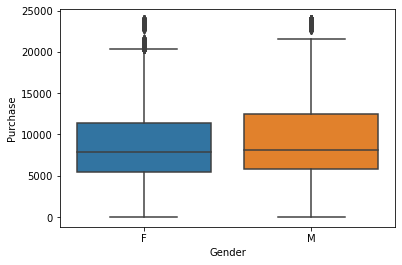

In [10]:
import seaborn as sbn

sbn.boxplot (x='Gender', y='Purchase', data=df)

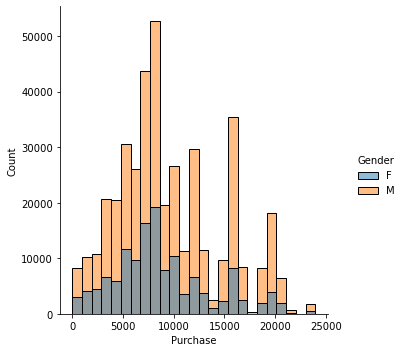

In [12]:
sbn.displot(hue='Gender', x='Purchase', data=df, bins=25)

In [13]:
df.groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,135809.0,8734.565765,4767.233289,12.0,5433.0,7914.0,11400.0,23959.0
M,414259.0,9437.526040,5092.186210,12.0,5863.0,8098.0,12454.0,23961.0


In [14]:
df.sample(300).groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,82.0,8114.597561,4823.499321,26.0,5314.5,7179.0,9908.50,20772.0
M,218.0,9653.366972,5645.668029,25.0,5207.5,8106.0,15242.25,23508.0


In [15]:
df.sample(300).groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,70.0,9038.557143,4574.980658,1418.0,5993.50,7918.0,11429.75,20061.0
M,230.0,8873.269565,5009.205477,141.0,5317.75,7966.5,11626.50,23349.0


In [16]:
df.sample(300).groupby('Gender')['Purchase'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
F,83.0,9462.265060,4783.470161,404.0,5923.5,8118.0,12562.5,23577.0
M,217.0,9393.764977,4989.058479,367.0,5880.0,8096.0,12042.0,23446.0


In [17]:
sample_size=300
iteration=1000


In [18]:
male_sample_means=[df[df['Gender']=='M'].sample(sample_size, replace=True)['Purchase'].mean() for i in range (iteration)]


In [19]:
females_sample_means=[df[df['Gender']=='F'].sample(sample_size, replace=True)['Purchase'].mean() for i in range (iteration)]


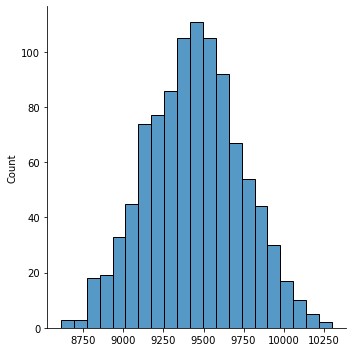

In [20]:
sbn.displot(male_sample_means)

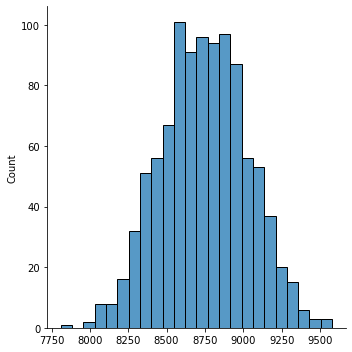

In [22]:
sbn.displot(females_sample_means)

In [23]:
import numpy as np
np.mean(male_sample_means)

9439.95974

In [24]:
#confidence interval

In [25]:
male_upper_limit = np.mean(male_sample_means) + 1.96 * np.std(male_sample_means)

In [26]:
male_lower_limit = np.mean(male_sample_means) - 1.96 * np.std(male_sample_means)

In [27]:
[male_lower_limit, male_upper_limit]

[8863.671859355685, 10016.247620644315]

In [30]:
female_upper_limit = np.mean(females_sample_means) + 1.96 * np.std(females_sample_means)

In [31]:
female_lower_limit = np.mean(females_sample_means) - 1.96 * np.std(females_sample_means)

In [32]:
[female_lower_limit, female_upper_limit]

[8198.169546657777, 9292.647586675557]

In [ ]:
#make sure that confidence interval do not overlap

In [ ]:
#percentile method

In [33]:
male_confidence_interval= np.percentile(male_sample_means, [2.5, 97.5])


In [34]:
female_confidence_interval= np.percentile(females_sample_means, [2.5, 97.5])

In [35]:
male_confidence_interval

array([ 8865.7605, 10021.6995])

In [36]:
female_confidence_interval

array([8230.10191667, 9288.27883333])